# Phase 1 — Data Quality Audit

Validates the price and macro panels ingested in Phase 1.

Sections:
1. Per-series coverage (rows per month)
2. Gaps longer than 5 business days
3. Return outliers (rolling |z| > 6)
4. Cross-source sanity: futures vs ETF return correlations

Anomalies found here should be summarised in `journal.md`.

In [1]:
import sys
from pathlib import Path

# Make `metals.*` importable when running the notebook from the notebooks/ folder.
src = Path.cwd().parent / "src" if Path.cwd().name == "notebooks" else Path.cwd() / "src"
if str(src) not in sys.path:
    sys.path.insert(0, str(src))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from metals.features.loaders import load_prices, load_macro
from metals.features.returns import compute_log_returns

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

In [2]:
prices = load_prices()    # wide: timestamp_utc × ticker, values = adj_close
macro  = load_macro()     # wide: timestamp_utc × series_id, values = value

print(f"prices: {prices.shape[0]:,} rows x {prices.shape[1]} tickers, "
      f"{prices.index.min().date()} -> {prices.index.max().date()}")
print(f"macro : {macro.shape[0]:,} rows x {macro.shape[1]} series, "
      f"{macro.index.min().date()} -> {macro.index.max().date()}")
print()
print("Tickers:", sorted(prices.columns))
print("Series :", sorted(macro.columns))

prices: 4,883 rows x 12 tickers, 2007-01-01 -> 2026-05-22
macro : 15,117 rows x 12 series, 1985-01-01 -> 2026-05-22

Tickers: ['CL=F', 'GC=F', 'GLD', 'HG=F', 'PA=F', 'PALL', 'PL=F', 'PPLT', 'SI=F', 'SLV', '^GSPC', '^VIX']
Series : ['BAMLH0A0HYM2', 'DFII10', 'DFII5', 'DGS10', 'DGS2', 'DGS3MO', 'DTWEXBGS', 'GPR_DAILY', 'T10YIE', 'T5YIE', 'VIXCLS', 'WALCL']


## 1. Coverage

Per-series start/end and total row count, then a heatmap of rows-per-month for each series. Macro series have natural frequency differences (e.g. WALCL is weekly, BAMLH0A0HYM2 has its own publication cadence) — the heatmap makes those visible.

In [3]:
def per_series_summary(wide: pd.DataFrame) -> pd.DataFrame:
    present = wide.notna()
    first = present.idxmax()
    last  = present[::-1].idxmax()
    return pd.DataFrame({
        "first": first,
        "last":  last,
        "rows":  present.sum(),
    }).sort_index()

print("Prices:"); print(per_series_summary(prices))
print(); print("Macro:"); print(per_series_summary(macro))

Prices:
            first       last  rows
ticker                            
CL=F   2007-01-02 2026-05-22  4879
GC=F   2007-01-02 2026-05-22  4878
GLD    2007-01-03 2026-05-22  4878
HG=F   2007-01-01 2026-05-22  4880
PA=F   2007-01-30 2026-05-22  4523
PALL   2010-01-08 2026-05-22  4118
PL=F   2007-01-02 2026-05-22  4470
PPLT   2010-01-08 2026-05-22  4118
SI=F   2007-01-02 2026-05-22  4878
SLV    2007-01-03 2026-05-22  4878
^GSPC  2007-01-03 2026-05-22  4878
^VIX   2007-01-03 2026-05-22  4878

Macro:
                  first       last   rows
series_id                                
BAMLH0A0HYM2 2023-05-23 2026-05-21    786
DFII10       2007-01-02 2026-05-21   4851
DFII5        2007-01-02 2026-05-21   4851
DGS10        2007-01-02 2026-05-21   4851
DGS2         2007-01-02 2026-05-21   4851
DGS3MO       2007-01-02 2026-05-21   4851
DTWEXBGS     2007-01-01 2026-05-15   4847
GPR_DAILY    1985-01-01 2026-05-18  15113
T10YIE       2007-01-02 2026-05-22   4852
T5YIE        2007-01-02 2026-05-

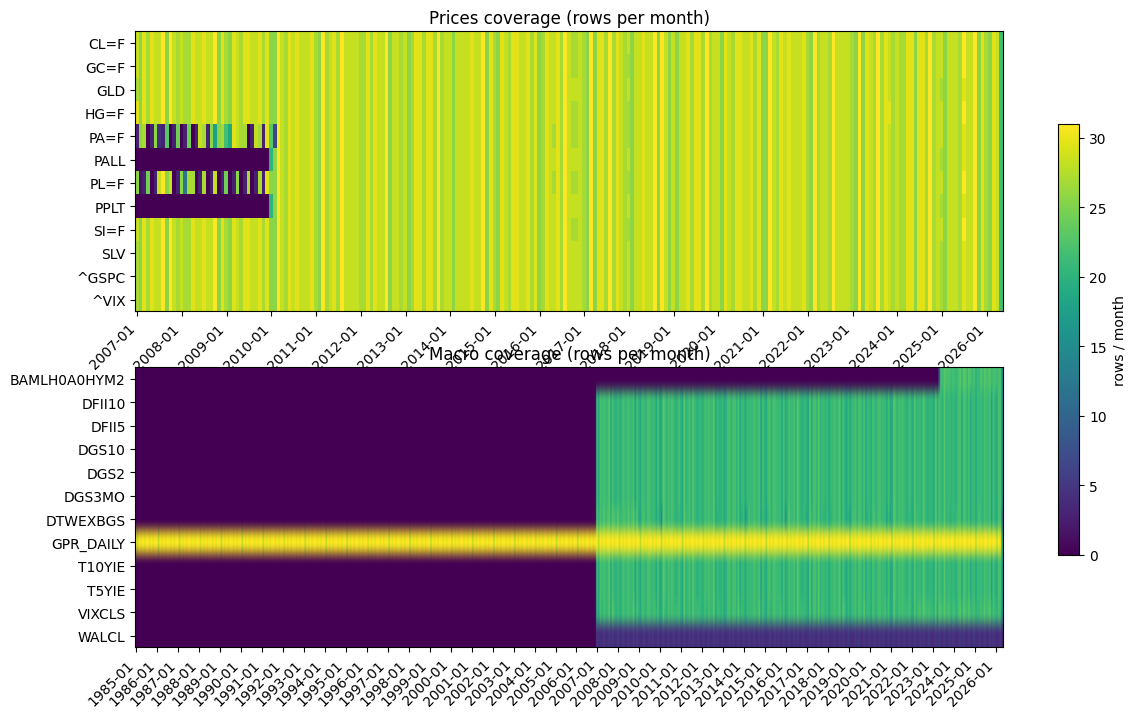

In [4]:
def monthly_rows(wide: pd.DataFrame) -> pd.DataFrame:
    long = wide.notna().stack().rename("p").reset_index()
    long.columns = ["t", "series", "p"]
    long["ym"] = long["t"].dt.to_period("M")
    return (long[long["p"]]
            .groupby(["series", "ym"]).size()
            .unstack("ym").fillna(0).astype(int))

def heatmap(df: pd.DataFrame, title: str, ax) -> any:
    im = ax.imshow(df.values, aspect="auto", cmap="viridis")
    ax.set_yticks(range(len(df.index)))
    ax.set_yticklabels(df.index)
    n = len(df.columns)
    tick = list(range(0, n, 12))
    ax.set_xticks(tick)
    ax.set_xticklabels([str(df.columns[i]) for i in tick], rotation=45, ha="right")
    ax.set_title(title)
    return im

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
heatmap(monthly_rows(prices), "Prices coverage (rows per month)", axes[0])
im = heatmap(monthly_rows(macro),  "Macro coverage (rows per month)",  axes[1])
fig.colorbar(im, ax=axes, label="rows / month", shrink=0.7)
plt.show()

## 2. Gap analysis

Flag any pair of consecutive observations more than 5 business days apart. Weekly series (WALCL) and series with monthly publication will trigger frequently — that's expected, not a bug; the goal is to surface *unexpected* holes in daily series.

In [5]:
def gap_report(wide: pd.DataFrame, threshold_bdays: int = 5) -> pd.DataFrame:
    rows = []
    for col in wide.columns:
        s = wide[col].dropna()
        if len(s) < 2:
            continue
        idx = pd.DatetimeIndex(s.index)
        # business-day distance between consecutive observations
        bdays = np.busday_count(
            idx[:-1].date.astype("datetime64[D]"),
            idx[1:].date.astype("datetime64[D]"),
        )
        for i, gap in enumerate(bdays):
            if gap > threshold_bdays:
                rows.append({
                    "series": col,
                    "after":  idx[i].date(),
                    "before": idx[i + 1].date(),
                    "business_day_gap": int(gap),
                })
    cols = ["series", "after", "before", "business_day_gap"]
    if not rows:
        return pd.DataFrame(columns=cols)
    return (pd.DataFrame(rows, columns=cols)
            .sort_values(["business_day_gap", "series"], ascending=[False, True])
            .reset_index(drop=True))

gaps_prices = gap_report(prices)
gaps_macro  = gap_report(macro)

print(f"Gaps > 5 business days — prices: {len(gaps_prices)} occurrences")
print(gaps_prices.head(15))
print()
print(f"Gaps > 5 business days — macro:  {len(gaps_macro)} occurrences")
print(gaps_macro.head(15))

Gaps > 5 business days — prices: 25 occurrences
   series       after      before  business_day_gap
0    PA=F  2007-09-26  2007-11-29                46
1    PA=F  2007-03-28  2007-05-30                45
2    PA=F  2007-12-27  2008-02-28                45
3    PA=F  2008-03-27  2008-05-29                45
4    PA=F  2009-06-26  2009-08-28                45
5    PL=F  2007-04-26  2007-06-28                45
6    PL=F  2007-10-29  2007-12-28                44
7    PL=F  2008-04-28  2008-06-27                44
8    PL=F  2008-07-29  2008-09-29                44
9    PL=F  2008-10-29  2008-12-30                44
10   PL=F  2009-04-28  2009-06-29                44
11   PL=F  2009-07-29  2009-09-29                44
12   PL=F  2009-01-28  2009-03-30                43
13   PA=F  2007-07-25  2007-08-30                26
14   PA=F  2008-07-29  2008-08-28                22

Gaps > 5 business days — macro:  0 occurrences
Empty DataFrame
Columns: [series, after, before, business_day_gap]
Index

## 3. Return outliers

Compute close-to-close log returns and flag observations whose rolling z-score (252-day window) exceeds 6 in absolute value. Real market shocks (e.g. COVID March 2020) will show up — the point is to make sure nothing impossible (data error, decimal-place glitch, split not adjusted) is present.

In [6]:
def outlier_returns(wide: pd.DataFrame, window: int = 252, z_threshold: float = 6.0) -> pd.DataFrame:
    # compute_log_returns masks non-positive prices (cf. WTI 2020-04-20) to NaN.
    rets = compute_log_returns(wide, horizons=(1,)).rename(
        columns=lambda c: c.replace("_ret_1d", "")
    )
    mu = rets.rolling(window, min_periods=60).mean()
    sd = rets.rolling(window, min_periods=60).std()
    z = (rets - mu) / sd
    out = (z.abs() > z_threshold).fillna(False)
    rows = []
    for col in out.columns:
        for t in z.index[out[col]]:
            rows.append({
                "series": col,
                "date":   t.date(),
                "return": float(rets.loc[t, col]),
                "z":      float(z.loc[t, col]),
            })
    cols = ["series", "date", "return", "z"]
    if not rows:
        return pd.DataFrame(columns=cols)
    return (pd.DataFrame(rows, columns=cols)
            .assign(abs_z=lambda d: d["z"].abs())
            .sort_values("abs_z", ascending=False)
            .drop(columns="abs_z")
            .reset_index(drop=True))

print("Return outliers in prices (|z| > 6 over 252-day rolling window):")
print(outlier_returns(prices).head(20))

Return outliers in prices (|z| > 6 over 252-day rolling window):
   series        date    return          z
0     SLV  2026-01-30 -0.336037 -10.777526
1    HG=F  2025-07-31 -0.251712 -10.393158
2    SI=F  2026-01-30 -0.376103 -10.334667
3    CL=F  2020-03-09 -0.282206  -9.747891
4    ^VIX  2018-02-05  0.768245   8.822050
5     GLD  2013-04-15 -0.091905  -8.732551
6    PA=F  2020-03-13 -0.233999  -8.619231
7    GC=F  2013-04-15 -0.098206  -8.588955
8    PALL  2020-03-12 -0.219713  -8.508211
9     SLV  2013-04-15 -0.134889  -7.990995
10   CL=F  2014-11-28 -0.107942  -7.988168
11  ^GSPC  2018-02-05 -0.041843  -7.986884
12   GC=F  2026-01-30 -0.120657  -7.879057
13   ^VIX  2024-08-05  0.500166   7.871802
14    SLV  2020-03-16 -0.131759  -7.864529
15   CL=F  2020-03-18 -0.279920  -7.859170
16  ^GSPC  2025-04-09  0.090895   7.786948
17  ^GSPC  2020-03-16 -0.127652  -7.656795
18   PPLT  2020-03-16 -0.144250  -7.608538
19   PPLT  2020-03-12 -0.125327  -7.528368


## 4. Cross-source sanity check

On overlapping dates, daily log-return correlation between each metal's futures contract and its ETF should be ≥ 0.95. A pair below that bar means an alignment or adjustment bug somewhere — investigate before using the panel for modeling.

In [7]:
pairs = [("GLD", "GC=F"), ("SLV", "SI=F"), ("PPLT", "PL=F"), ("PALL", "PA=F")]
rets = compute_log_returns(prices, horizons=(1,)).rename(
    columns=lambda c: c.replace("_ret_1d", "")
)

rows = []
for etf, fut in pairs:
    if etf not in rets.columns or fut not in rets.columns:
        rows.append({"etf": etf, "futures": fut, "overlap_rows": 0,
                     "correlation": np.nan, "passes_0.95": False})
        continue
    both = rets[[etf, fut]].dropna()
    c = both[etf].corr(both[fut]) if not both.empty else np.nan
    rows.append({
        "etf": etf,
        "futures": fut,
        "overlap_rows": len(both),
        "correlation": round(c, 4) if pd.notna(c) else np.nan,
        "passes_0.95": bool(pd.notna(c) and c >= 0.95),
    })

pd.DataFrame(rows)

,etf,futures,overlap_rows,correlation,passes_0.95
0,GLD,GC=F,4868,0.8861,False
1,SLV,SI=F,4868,0.8991,False
2,PPLT,PL=F,4106,0.9184,False
3,PALL,PA=F,4089,0.9103,False


## 5. Findings

Anomalies surfaced by this audit (first executed 2026-05-24):

### Blocking (must address before Phase 1.14 baseline)

- **ETF/futures correlations all below the 0.95 plan threshold** (GLD/GC=F 0.886, SLV/SI=F 0.899, PPLT/PL=F 0.918, PALL/PA=F 0.910). Almost certainly a close-time mismatch — COMEX futures close at 1:30 ET, ETFs at 4:00 ET, so close-to-close returns cover non-overlapping 22.5-hour windows on each side. Plan step 1.7 anticipates this. Options: (a) revise the audit threshold for close-to-close pairs, (b) align via intraday or via open-to-close-of-futures, (c) accept and document.
- **BAMLH0A0HYM2 only goes back to 2023-05-23** (786 rows, vs ~4,800 expected from 2007). FRED still hosts this series; the truncation is likely a series-ID rename or coverage change. Re-source before relying on credit-spread features.

### Non-blocking but document

- **Platinum/palladium futures (PL=F, PA=F) have ~45 business-day gaps in 2007–2009.** PA=F starts 2007-01-30, PL=F has multiple month-long gaps through 2009. Both reflect real thin trading / contract-rolling history; PPLT and PALL ETFs only start 2010-01-08 (correct, fund inception). Models depending on these series should start in 2010 or later, or explicitly handle the early-year gaps.
- **All detected return outliers (>6σ) correspond to real events**: COVID March 2020, 2013-04-15 gold flash crash, 2018-02-05 VIX explosion, 2024-08-05 yen carry-trade unwind, 2025-04-09 tariff news, 2026-01-30 silver/gold/copper move. Worth a manual eyeball on 2026-01-30 SLV at -33.6%; if confirmed real this is the largest move in the panel.
- **`np.log` invalid-value RuntimeWarning** during return computation — at least one zero or negative price somewhere. Trace and decide whether to drop or interpolate before training.